# LASSO und Ridge Regression zur Inflationsprognose
## Empirische Analyse mit deutschen Makrodaten

**Seminararbeit**: Aktuelle Fragen der Ökonometrie
**Betreuer**: Prof. Bernhard Schipp | Technische Universität Dresden

---

**Aufbau:**
1. Datenbeschaffung & -aufbereitung (ECB + Eurostat API)
2. Explorative Datenanalyse
3. Modelle: OLS, Ridge, LASSO
4. Cross-Validation mit TimeSeriesSplit (λ-Selektion)
5. Ergebnisvergleich (MSE, RMSE)
6. Visualisierungen: Koeffizientenpfade, Shrinkage-Plots

**Zielvariable (Y):** HVPI-Inflationsrate Deutschland (YoY, in %)
**Prädiktoren (X):** 33 makroökonomische Indikatoren aus 4 Kategorien → 165 Features mit Lags


In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ── Projekt-Setup: Pfade robust auflösen (Start aus Projektwurzel ODER notebooks/) ──
import os, pathlib
_ROOT = pathlib.Path.cwd()
if _ROOT.name == "notebooks":          # Start aus dem notebooks/-Ordner
    _ROOT = _ROOT.parent
os.chdir(_ROOT)
(_ROOT / "results" / "figures").mkdir(parents=True, exist_ok=True)
(_ROOT / "data" / "raw").mkdir(parents=True, exist_ok=True)
(_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)

import requests, time
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso,
    LassoCV, RidgeCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# Plot-Stil
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.figsize": (12, 5),
})
COLORS = {"OLS": "#2196F3", "Ridge": "#FF9800", "LASSO": "#4CAF50"}

print("Alle Bibliotheken geladen. Projektwurzel:", _ROOT)

## 0. Datenfunktionen (ECB + Eurostat) 
Diese Funktionen ersetzen das frühere Skript `src/data_loader.py`. Sie laden die Zeitreihen direkt von der **ECB** (Statistical Data Warehouse) und von **Eurostat**, transformieren sie in YoY-Veränderungsraten und bauen die verlagerte Feature-Matrix.

In [ ]:
# Datenbeschaffung: Quellen: ECB Statistical Data Warehouse + Eurostat Dissemination API.
ECB_BASE   = "https://data-api.ecb.europa.eu/service/data"
ESTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"


def _fetch_ecb_series(flow_key, start="2000-01"):
    """Laedt eine monatliche Zeitreihe vom ECB SDW (CSV-Format)."""
    r = requests.get(f"{ECB_BASE}/{flow_key}",
                     params={"startPeriod": start, "format": "csvdata"}, timeout=30)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text))
    df["TIME_PERIOD"] = pd.to_datetime(df["TIME_PERIOD"], format="%Y-%m")
    df = df.set_index("TIME_PERIOD").sort_index()
    return df["OBS_VALUE"].astype(float)


def _eurostat_json_to_series(data, freq="M"):
    """Konvertiert eine Eurostat-JSON-Antwort in eine pd.Series."""
    time_dim = data["dimension"]["time"]
    pos_to_label = {v: k for k, v in time_dim["category"]["index"].items()}
    records = []
    for pos_str, val in data["value"].items():
        label = pos_to_label[int(pos_str)]
        if freq == "Q":
            year, q = label.split("-Q")
            month = (int(q) - 1) * 3 + 1
            date = pd.Timestamp(f"{year}-{month:02d}-01")
        else:
            date = pd.to_datetime(label, format="%Y-%m")
        records.append((date, float(val)))
    if not records:
        return pd.Series(dtype=float)
    s = pd.Series(dict(records)).sort_index()
    s.index = pd.DatetimeIndex(s.index)
    return s


def _fetch_eurostat(dataset, params, start_year=2000, freq="M"):
    """Laedt eine Zeitreihe von Eurostat und filtert ab start_year."""
    r = requests.get(f"{ESTAT_BASE}/{dataset}",
                     params={**params, "format": "JSON"}, timeout=30)
    r.raise_for_status()
    s = _eurostat_json_to_series(r.json(), freq=freq)
    return s[s.index.year >= start_year]


# ── Datensatz-Definitionen ───────────────────────────────────────────────────
PROD_SECTORS = {
    "IP_Verarbeitendes_Gew": "C",     "IP_Nahrungs_Genuss":   "C10-C12",
    "IP_Textil_Leder":       "C13-C15", "IP_Holz_Papier_Druck": "C16-C18",
    "IP_Mineraloel":         "C19",    "IP_Chemie":            "C20",
    "IP_Pharma":             "C21",    "IP_Metall_Grundstoffe": "C24",
    "IP_Metallerzeugnisse":  "C25",    "IP_DV_Elektronik":     "C26",
    "IP_Elektrisch":         "C27",    "IP_Maschinenbau":      "C28",
    "IP_Kfz":                "C29",    "IP_Sonstiger_Fahrzeug": "C30",
    "IP_Energie":            "D",
}
BS_INDICATORS = {
    "BS_Konjunkturklima":   "BS-ICI",  "BS_Produktionserwart":  "BS-IEME",
    "BS_Produktionstendenz": "BS-IPT", "BS_Absatzpreise":       "BS-ISFP",
    "BS_Auftragsbestand":   "BS-IOB",
}
PPI_SECTORS = {
    "PPI_Gesamt": "B-E36", "PPI_Konsumgueter": "MIG_COG", "PPI_Vorleistungen": "MIG_ING",
}
UNEMP_GROUPS = {
    "ALQ_Gesamt":   {"sex": "T", "age": "TOTAL"},
    "ALQ_Maenner":  {"sex": "M", "age": "TOTAL"},
    "ALQ_Frauen":   {"sex": "F", "age": "TOTAL"},
    "ALQ_Kern_Ges": {"sex": "T", "age": "Y25-74"},
    "ALQ_Kern_M":   {"sex": "M", "age": "Y25-74"},
    "ALQ_Kern_F":   {"sex": "F", "age": "Y25-74"},
}
LCI_SERIES = {
    "LCI_Lohnkosten_BN":  {"nace_r2": "B-N", "lcstruct": "D1_D4_MD5"},
    "LCI_Loehne_BN":      {"nace_r2": "B-N", "lcstruct": "D11"},
    "LCI_Lohnkosten_Ind": {"nace_r2": "B-F", "lcstruct": "D1_D4_MD5"},
    "LCI_Loehne_Ind":     {"nace_r2": "B-F", "lcstruct": "D11"},
}


def load_all_data(verbose=True):
    """Laedt alle Zeitreihen von ECB + Eurostat und gibt einen DataFrame zurueck."""
    series_dict = {}

    def _log(name, s):
        if verbose and len(s) > 0:
            print(f"  + {name:35s} [{len(s):3d} obs, "
                  f"{s.index[0]:%Y-%m} - {s.index[-1]:%Y-%m}]")

    if verbose:
        print("\n-- Zielvariable -------------------------------------------------")
    s = _fetch_ecb_series("ICP/M.DE.N.000000.4.INX")
    series_dict["HVPI"] = s
    _log("HVPI (Gesamtindex 2015=100)", s)
    time.sleep(0.3)

    blocks = [
        ("Industrieproduktion", "sts_inpr_m",
         lambda nace: {"geo": "DE", "s_adj": "NSA", "unit": "I15", "nace_r2": nace},
         PROD_SECTORS, "M"),
        ("Business Surveys", "ei_bsin_m_r2",
         lambda indic: {"geo": "DE", "s_adj": "SA", "indic": indic},
         BS_INDICATORS, "M"),
        ("Produzentenpreise", "sts_inppd_m",
         lambda nace: {"geo": "DE", "s_adj": "NSA", "unit": "I15", "nace_r2": nace},
         PPI_SECTORS, "M"),
        ("Arbeitsmarkt", "une_rt_m",
         lambda grp: {"geo": "DE", "s_adj": "SA", "unit": "PC_ACT", **grp},
         UNEMP_GROUPS, "M"),
    ]
    for title, dataset, mk_params, defs, freq in blocks:
        if verbose:
            print(f"\n-- {title} " + "-" * max(0, 50 - len(title)))
        for name, val in defs.items():
            try:
                s = _fetch_eurostat(dataset, mk_params(val), freq=freq)
                if len(s) > 0:
                    series_dict[name] = s
                    _log(name, s)
            except Exception as e:
                if verbose:
                    print(f"  x {name}: {e}")
            time.sleep(0.2)

    # Lohnkosten (Quartal -> Monat, Treppenfunktion via ffill – kein Look-ahead)
    if verbose:
        print("\n-- Lohnkosten (LCI, Quartal -> Monat) ---------------------------")
    for name, flt in LCI_SERIES.items():
        try:
            s_q = _fetch_eurostat("lc_lci_r2_q",
                                  {"geo": "DE", "s_adj": "NSA", "unit": "I20", **flt},
                                  freq="Q")
            if len(s_q) > 0:
                s_m = s_q.resample("MS").ffill()
                series_dict[name] = s_m
                _log(name, s_m)
        except Exception as e:
            if verbose:
                print(f"  x {name}: {e}")
        time.sleep(0.2)

    df = pd.DataFrame(series_dict)
    df.index = pd.DatetimeIndex(df.index)
    df = df.sort_index()
    if verbose:
        print(f"\n+ Rohdaten: {df.shape[0]} Perioden x {df.shape[1]} Variablen "
              f"({df.index[0]:%Y-%m} - {df.index[-1]:%Y-%m})")
    return df


def get_raw_data(use_cache=True, save=True, verbose=True):
    """Liefert die Rohdaten – aus dem CSV-Cache (data/raw/) oder frisch von der API.

    use_cache=True  -> liest data/raw/data_raw.csv, falls vorhanden (schnell, offline).
    use_cache=False -> erzwingt einen neuen API-Download (~1-2 Minuten).
    save=True       -> speichert einen frischen Download als Cache.
    """
    cache = pathlib.Path("data/raw/data_raw.csv")
    if use_cache and cache.exists():
        if verbose:
            print(f"Rohdaten aus Cache geladen: {cache}")
        return pd.read_csv(cache, index_col=0, parse_dates=True)

    df = load_all_data(verbose=verbose)
    if save:
        df.to_csv(cache)
        if verbose:
            print(f"Rohdaten als Cache gespeichert: {cache}")
    return df


def transform_to_yoy(df):
    """Transformiert alle Spalten in YoY-Veraenderungsraten (%) -> stationaer."""
    df_yoy = df.pct_change(12) * 100
    return df_yoy.replace([np.inf, -np.inf], np.nan)


def build_feature_matrix(df_yoy, lags=[1, 2, 3, 6, 12],
                         target_col="HVPI", forecast_horizon=1,
                         test_months=36):
    """Erstellt leckage-freie Feature-Matrix X (verlagerte Praediktoren) und Ziel y."""
    predictor_cols = [c for c in df_yoy.columns if c != target_col]
    frames = []
    for lag in lags:
        lagged = df_yoy[predictor_cols].shift(lag + forecast_horizon - 1)
        lagged.columns = [f"{c}_L{lag}" for c in predictor_cols]
        frames.append(lagged)
    X = pd.concat(frames, axis=1)
    y = df_yoy[target_col]

    # NaN-Filter nur auf Train-Anteil, um Leakage aus Test-Missingness zu vermeiden
    train_end_approx = len(X) - test_months
    nan_frac = X.iloc[:train_end_approx].isna().mean()
    X = X.loc[:, nan_frac <= 0.20]

    combined = pd.concat([X, y], axis=1).dropna()
    return combined.drop(columns=[target_col]), combined[target_col]


print("Datenfunktionen definiert (load_all_data, get_raw_data, transform_to_yoy, build_feature_matrix).")

## 1. Datenbeschaffung & -aufbereitung

In [3]:
# Rohdaten laden: nutzt den CSV-Cache in data/raw/ falls vorhanden,
# sonst Frisch-Download von ECB + Eurostat (~1-2 Minuten) inkl. erneutem Cachen.
# Fuer einen garantiert frischen Abruf: get_raw_data(use_cache=False)
df_raw = get_raw_data(use_cache=True, verbose=True)
df_raw.head(3)


Rohdaten aus Cache geladen: data/raw/data_raw.csv


,HVPI,IP_Verarbeitendes_Gew,IP_Nahrungs_Genuss,IP_Textil_Leder,IP_Holz_Papier_Druck,IP_Mineraloel,IP_Chemie,IP_Pharma,IP_Metall_Grundstoffe,IP_Metallerzeugnisse,...,ALQ_Gesamt,ALQ_Maenner,ALQ_Frauen,ALQ_Kern_Ges,ALQ_Kern_M,ALQ_Kern_F,LCI_Lohnkosten_BN,LCI_Loehne_BN,LCI_Lohnkosten_Ind,LCI_Loehne_Ind
2000-01-01,78.5,68.8,83.3,198.1,88.7,104.5,91.4,51.0,88.1,66.9,...,8.2,7.8,8.6,8.1,7.6,8.8,58.700000,56.900000,58.200000,56.900000
2000-02-01,78.6,77.2,87.0,211.4,96.4,97.1,94.0,55.7,95.9,74.4,...,8.1,7.8,8.6,8.0,7.5,8.7,62.466667,60.933333,62.366667,61.366667
2000-03-01,78.6,86.1,96.9,215.7,105.0,103.4,99.2,59.4,106.2,82.6,...,8.1,7.7,8.5,8.0,7.5,8.6,66.233333,64.966667,66.533333,65.833333


In [ ]:
# AP1.2: LCI-Cache einmalig von linearer Interpolation auf ffill korrigieren.
# Quartalsstartwerte (Monate 1, 4, 7, 10) sind die echten Quartalswerte;
# Zwischenmonate bekommen per ffill den jeweils letzten Quartalsstand.
_lci_cols = [c for c in df_raw.columns if c.startswith("LCI_")]
for _col in _lci_cols:
    _s = df_raw[_col].copy()
    _s[~_s.index.month.isin([1, 4, 7, 10])] = np.nan
    df_raw[_col] = _s.ffill()
df_raw.to_csv("data/raw/data_raw.csv")
print(f"LCI-Spalten im Cache auf ffill korrigiert: {_lci_cols}")

In [4]:
# YoY-Transformierung: Stationarisierung + oekonomisch interpretierbare Veraenderungsraten
df_yoy = transform_to_yoy(df_raw)
df_yoy.to_csv("data/processed/data_yoy.csv")   # aufbereitete Daten ablegen

# Feature-Matrix mit Lags aufbauen
# Lags 1, 2, 3, 6, 12 Monate -> keine Datenleckage (Prognose-Horizont = 1 Monat)
X, y = build_feature_matrix(df_yoy, lags=[1, 2, 3, 6, 12], forecast_horizon=1)

print(f"Feature-Matrix:  {X.shape[0]} Beobachtungen x {X.shape[1]} Features")
print(f"Zielvariable:    {len(y)} Beobachtungen")
print(f"Zeitraum:        {y.index[0]:%Y-%m} - {y.index[-1]:%Y-%m}")
print(f"\nAnteil NaN in X: {X.isna().mean().mean():.1%}")


Feature-Matrix:  254 Beobachtungen x 165 Features
Zielvariable:    254 Beobachtungen
Zeitraum:        2002-01 - 2024-01

Anteil NaN in X: 0.0%


In [ ]:
# AP1.5: Stichproben-Truncation diagnostizieren
# Zeigt, welche Reihen die Feature-Matrix zeitlich beschneiden.
_last_obs = df_raw.apply(lambda s: s.last_valid_index())
print("Letzte gültige Beobachtung je Reihe (kürzeste zuerst):")
print(_last_obs.sort_values().head(8).to_string())
_gap = (
    (df_raw.index[-1].year - y.index[-1].year) * 12
    + df_raw.index[-1].month - y.index[-1].month
)
print(f"\nRohdaten bis:        {df_raw.index[-1]:%Y-%m}")
print(f"Feature-Matrix bis:  {y.index[-1]:%Y-%m}")
print(f"Ungenutzte Monate:   {_gap}")
print("Grund: kürzeste Reihe in obiger Liste bestimmt das Enddatum der Feature-Matrix.")

## 2. Explorative Datenanalyse

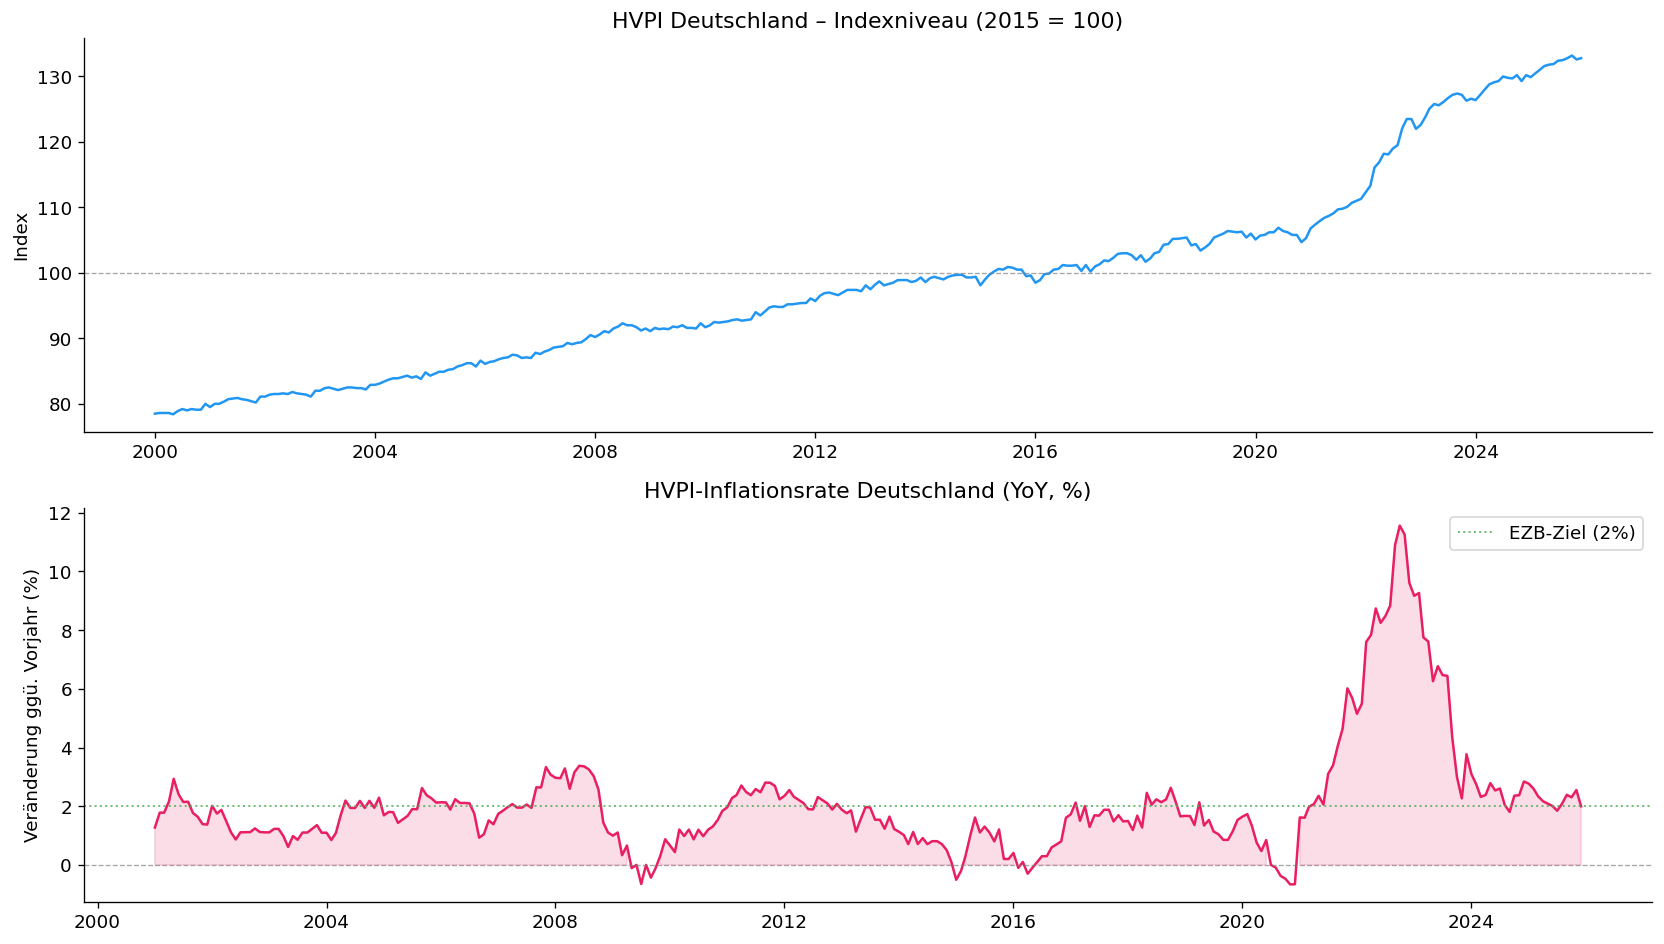

Abbildung gespeichert: fig_01_hvpi_zeitreihe.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# HVPI Indexniveau (Rohdaten)
hvpi_raw = df_raw["HVPI"].dropna()
axes[0].plot(hvpi_raw.index, hvpi_raw.values, color="#2196F3", linewidth=1.5)
axes[0].set_title("HVPI Deutschland – Indexniveau (2015 = 100)")
axes[0].set_ylabel("Index")
axes[0].axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

# HVPI YoY-Inflationsrate
hvpi_yoy = df_yoy["HVPI"].dropna()
axes[1].plot(hvpi_yoy.index, hvpi_yoy.values, color="#E91E63", linewidth=1.5)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[1].axhline(2, color="#4CAF50", linestyle=":", linewidth=1.2, alpha=0.8,
                label="EZB-Ziel (2%)")
axes[1].fill_between(hvpi_yoy.index, hvpi_yoy.values, 0,
                     where=hvpi_yoy.values > 0, alpha=0.15, color="#E91E63")
axes[1].set_title("HVPI-Inflationsrate Deutschland (YoY, %)")
axes[1].set_ylabel("Veränderung ggü. Vorjahr (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/figures/fig_01_hvpi_zeitreihe.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_01_hvpi_zeitreihe.png")


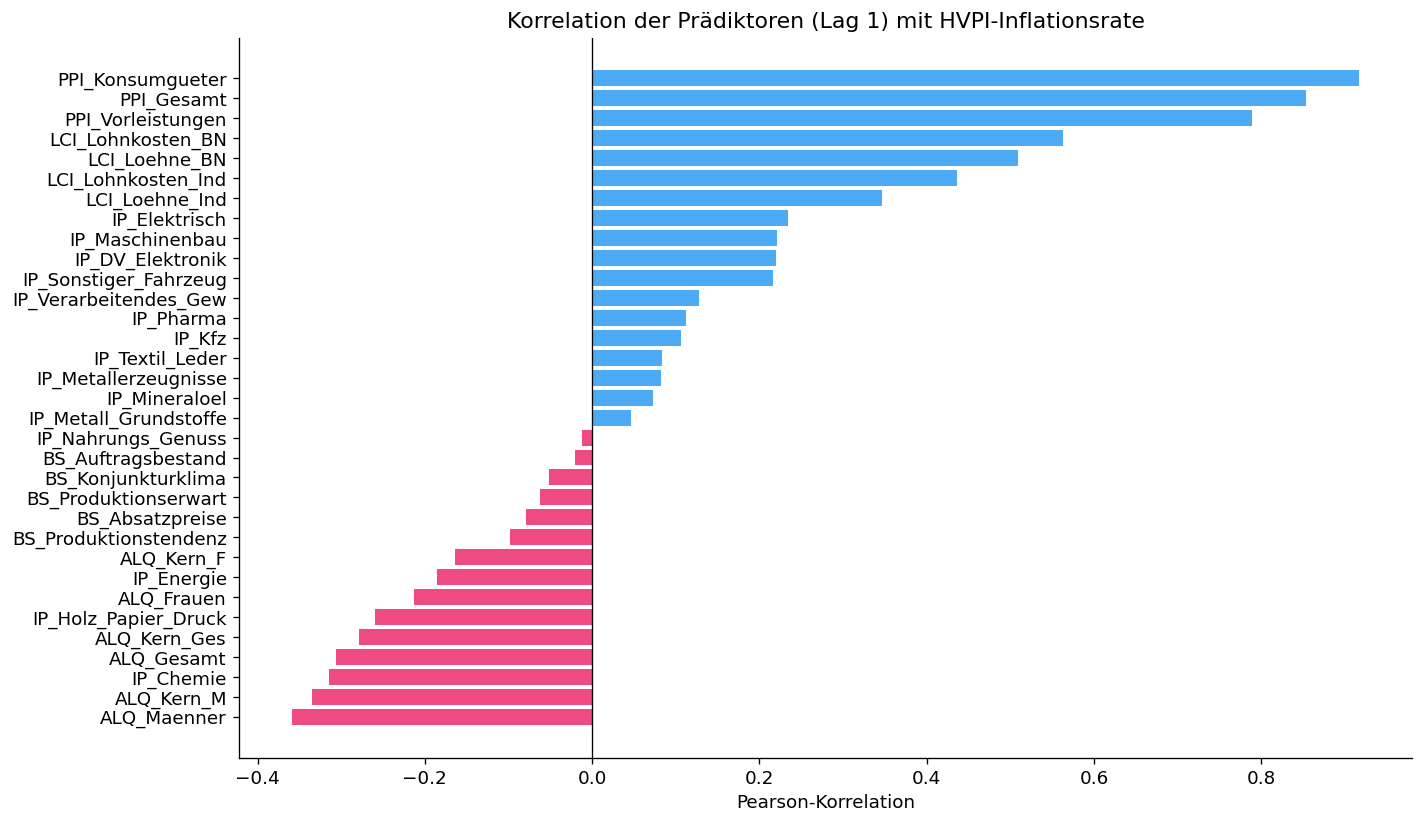

Abbildung gespeichert: fig_02_korrelation.png


In [6]:
# Korrelation der Prädikatoren (Lag 1) mit der HVPI-Inflationsrate
pred_cols_l1 = [c for c in X.columns if c.endswith("_L1")]
corr_with_y = (
    X[pred_cols_l1].corrwith(y)
    .rename(lambda c: c.replace("_L1", ""))
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#E91E63" if v < 0 else "#2196F3" for v in corr_with_y.values]
ax.barh(corr_with_y.index, corr_with_y.values, color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Korrelation der Prädiktoren (Lag 1) mit HVPI-Inflationsrate")
ax.set_xlabel("Pearson-Korrelation")
plt.tight_layout()
plt.savefig("results/figures/fig_02_korrelation.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_02_korrelation.png")


### 2b. Multikollinearität der Prädiktoren

In [ ]:
# ── Multikollinearität der Prädiktoren (motiviert Ridge) ─────────────────────
# fig_02 zeigt Korrelation mit y; hier: Korrelationen *unter* den Prädiktoren.
# Hohe gegenseitige Korrelationen → schlecht konditioniertes X'X → OLS-Overfitting.
pred_l1 = X_train[[c for c in X_train.columns if c.endswith("_L1")]]

fig, ax = plt.subplots(figsize=(13, 11))
corr_pred = pred_l1.corr()
mask = np.triu(np.ones_like(corr_pred, dtype=bool))
sns.heatmap(
    corr_pred, mask=mask, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.3, ax=ax,
    xticklabels=[c.replace("_L1", "") for c in pred_l1.columns],
    yticklabels=[c.replace("_L1", "") for c in pred_l1.columns],
)
ax.set_title("Korrelationsmatrix der Prädiktoren (Lag 1) — Trainingsset")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("results/figures/fig_02b_korr_heatmap.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_02b_korr_heatmap.png")

# Konditionszahl von X'X (standardisiert)
cond_XtX = np.linalg.cond(X_train_s.T @ X_train_s)
print(f"\nKonditionszahl von X'X (standardisiert): {cond_XtX:.2e}")
print("→ Werte >> 1 bestätigen starke Multikollinearität und erklären OLS-Instabilität.")

## 3. Modellschätzung: OLS, Ridge, LASSO

In [7]:
# Train/Test-Split: letzte 36 Monate als Testset (ca. 2021–2024)
# Bewusst chronologisch, kein zufälliges Split!
TEST_MONTHS = 36
train_end = len(y) - TEST_MONTHS

X_train, X_test = X.iloc[:train_end], X.iloc[train_end:]
y_train, y_test = y.iloc[:train_end], y.iloc[train_end:]

print(f"Trainingsdaten: {len(y_train)} Monate "
      f"({y_train.index[0].strftime('%Y-%m')} – {y_train.index[-1].strftime('%Y-%m')})")
print(f"Testdaten:      {len(y_test)} Monate "
      f"({y_test.index[0].strftime('%Y-%m')} – {y_test.index[-1].strftime('%Y-%m')})")
print(f"\nDimensionen: {X_train.shape[0]} Train × {X_train.shape[1]} Features")
print(f"n < p: {'JA (hochdimensional)' if X_train.shape[0] < X_train.shape[1] else 'NEIN'}")


Trainingsdaten: 218 Monate (2002-01 – 2020-10)
Testdaten:      36 Monate (2020-11 – 2024-01)

Dimensionen: 218 Train × 165 Features
n < p: NEIN


In [8]:
# Standardisierung zwingend vor Ridge/LASSO!
# Nur auf Trainingsdaten fitten → Test-Daten transformieren
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Standardisierung abgeschlossen.")
print(f"Trainings-Mittelwerte ~0: {np.abs(X_train_s.mean(axis=0)).max():.2e}")
print(f"Trainings-Std ~1:         {np.abs(X_train_s.std(axis=0) - 1).max():.2e}")


Standardisierung abgeschlossen.
Trainings-Mittelwerte ~0: 3.42e-16
Trainings-Std ~1:         3.33e-16


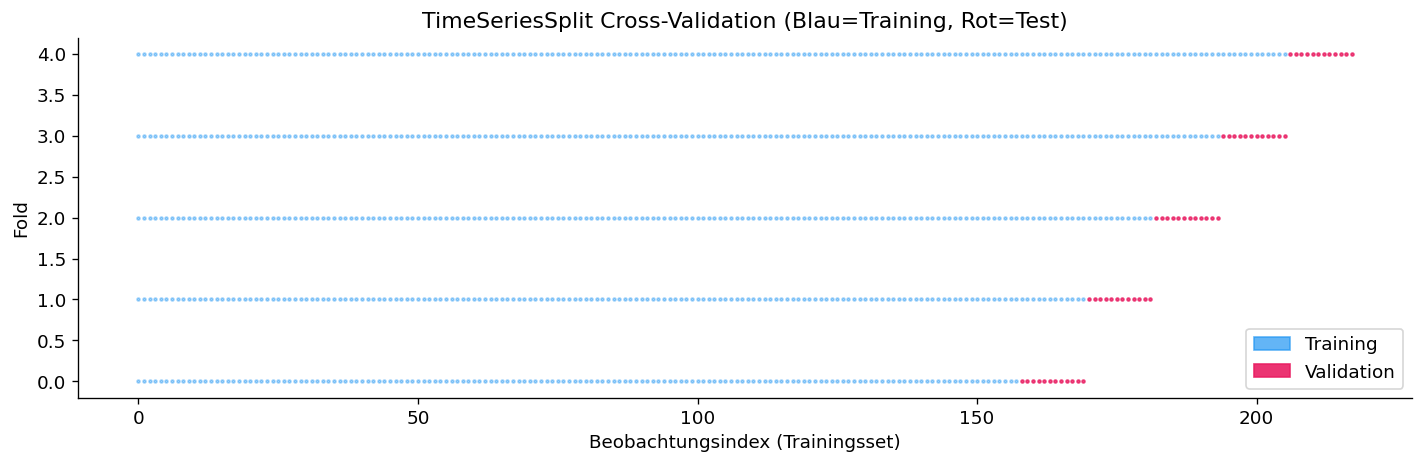

In [9]:
# TimeSeriesSplit: kein zufälliges k-fold bei Zeitreihen!
# Jeder Fold trainiert auf der Vergangenheit und testet auf der Zukunft.
tscv = TimeSeriesSplit(n_splits=5, test_size=12)  # 12 Monate pro Test-Fold

# Visualisierung der CV-Splits
fig, ax = plt.subplots(figsize=(12, 4))
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_train_s)):
    ax.scatter(tr_idx, [fold] * len(tr_idx), s=3, color="#2196F3", alpha=0.4)
    ax.scatter(te_idx, [fold] * len(te_idx), s=3, color="#E91E63", alpha=0.8)

ax.set_xlabel("Beobachtungsindex (Trainingsset)")
ax.set_ylabel("Fold")
ax.set_title("TimeSeriesSplit Cross-Validation (Blau=Training, Rot=Test)")
# Legende
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2196F3", alpha=0.7, label="Training"),
    Patch(color="#E91E63", alpha=0.9, label="Validation"),
])
plt.tight_layout()
plt.savefig("results/figures/fig_03_tscv.png", bbox_inches="tight")
plt.show()


## 3.5 Benchmarks: Random Walk & AR(p)

In [ ]:
# ── Random Walk Benchmark ──────────────────────────────────────────────────────
# ŷ_t = y_{t-1}: naivste Prognose, kein Training nötig.
AR_LAGS = [1, 2, 3, 6, 12]   # gemeinsame Lag-Liste für AR & LASSO+HVPI

y_pred_rw_test = y.shift(1).loc[y_test.index]

mse_rw_test  = mean_squared_error(y_test, y_pred_rw_test)
r2_rw_test   = r2_score(y_test, y_pred_rw_test)
rmse_rw_test = np.sqrt(mse_rw_test)
print(f"Random Walk – Test MSE: {mse_rw_test:.4f}  |  RMSE: {rmse_rw_test:.4f}  |  R²: {r2_rw_test:.4f}")

In [ ]:
# ── AR(p) Benchmark ────────────────────────────────────────────────────────────
# HVPI-Eigen-Lags als Prädiktoren; LinearRegression (sklearn-only, kein statsmodels)
X_ar = pd.DataFrame({f"HVPI_L{l}": y.shift(l) for l in AR_LAGS}).loc[y.index].dropna()
y_ar = y.loc[X_ar.index]

X_ar_train = X_ar.loc[X_ar.index <= y_train.index[-1]]
X_ar_test  = X_ar.loc[X_ar.index.isin(y_test.index)]
y_ar_train = y_ar.loc[X_ar_train.index]

sc_ar = StandardScaler()
ar_model = LinearRegression()
ar_model.fit(sc_ar.fit_transform(X_ar_train), y_ar_train)
y_pred_ar_test = pd.Series(
    ar_model.predict(sc_ar.transform(X_ar_test)), index=X_ar_test.index
)

mse_ar_test  = mean_squared_error(y_test, y_pred_ar_test)
r2_ar_test   = r2_score(y_test, y_pred_ar_test)
rmse_ar_test = np.sqrt(mse_ar_test)
print(f"AR(p)      – Test MSE: {mse_ar_test:.4f}  |  RMSE: {rmse_ar_test:.4f}  |  R²: {r2_ar_test:.4f}")

In [ ]:
# ── LASSO + HVPI-Eigen-Lags (Makro-Mehrwert) ──────────────────────────────────
# Testet, ob Makro-Prädiktoren über die Inflationspersistenz hinaus beitragen.
X_plus = X.copy()
for l in AR_LAGS:
    X_plus[f"HVPI_L{l}"] = y.shift(l)
X_plus = X_plus.loc[y.index].dropna()
y_plus = y.loc[X_plus.index]

X_plus_train = X_plus.loc[X_plus.index <= y_train.index[-1]]
X_plus_test  = X_plus.loc[X_plus.index.isin(y_test.index)]
y_plus_train = y_plus.loc[X_plus_train.index]

sc_plus = StandardScaler()
X_plus_train_s = sc_plus.fit_transform(X_plus_train)
X_plus_test_s  = sc_plus.transform(X_plus_test)

lasso_plus_cv = LassoCV(
    alphas=np.logspace(-3, 1, 100), cv=tscv, max_iter=10000, n_jobs=-1
)
lasso_plus_cv.fit(X_plus_train_s, y_plus_train)

y_pred_lasso_plus_test = pd.Series(
    lasso_plus_cv.predict(X_plus_test_s), index=X_plus_test.index
)
mse_lasso_plus_test  = mean_squared_error(y_test, y_pred_lasso_plus_test)
r2_lasso_plus_test   = r2_score(y_test, y_pred_lasso_plus_test)
rmse_lasso_plus_test = np.sqrt(mse_lasso_plus_test)
n_nonzero_plus       = int(np.sum(lasso_plus_cv.coef_ != 0))

print(f"LASSO+HVPI – λ={lasso_plus_cv.alpha_:.5f}, "
      f"MSE={mse_lasso_plus_test:.4f}, RMSE={rmse_lasso_plus_test:.4f}, "
      f"R²={r2_lasso_plus_test:.4f}, Koeff.≠0: {n_nonzero_plus}/{X_plus_train.shape[1]}")

In [ ]:
# ── OLS ──────────────────────────────────────────────────────────────────────
# p/n ≈ 0,76 + starke Multikollinearität → Overfitting; sklearn löst via Pseudo-Inverse
ols = LinearRegression()
ols.fit(X_train_s, y_train)

y_pred_ols_train = ols.predict(X_train_s)
y_pred_ols_test  = ols.predict(X_test_s)

mse_ols_train = mean_squared_error(y_train, y_pred_ols_train)
mse_ols_test  = mean_squared_error(y_test,  y_pred_ols_test)
r2_ols_test   = r2_score(y_test, y_pred_ols_test)

print(f"OLS – Train MSE: {mse_ols_train:.4f}  |  Test MSE: {mse_ols_test:.4f}")
print(f"OLS – Test R²:   {r2_ols_test:.4f}")
print(f"OLS – Nicht-Null-Koeffizienten: {np.sum(ols.coef_ != 0)}/{len(ols.coef_)}")

In [ ]:
# Ridge Regression 
# L2-Regularisierung: schrumpft alle Koeffizienten, setzt keine auf null
alphas_ridge = np.logspace(-2, 4, 100)

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=tscv, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train_s, y_train)

lambda_ridge = ridge_cv.alpha_
print(f"Ridge – Optimales λ (Cross-Validation): {lambda_ridge:.4f}")

y_pred_ridge_train = ridge_cv.predict(X_train_s)
y_pred_ridge_test  = ridge_cv.predict(X_test_s)

mse_ridge_train = mean_squared_error(y_train, y_pred_ridge_train)
mse_ridge_test  = mean_squared_error(y_test,  y_pred_ridge_test)
r2_ridge_test   = r2_score(y_test, y_pred_ridge_test)

print(f"Ridge – Train MSE: {mse_ridge_train:.4f}  |  Test MSE: {mse_ridge_test:.4f}")
print(f"Ridge – Test R²:   {r2_ridge_test:.4f}")
print(f"Ridge – Max |Koeff.|: {np.abs(ridge_cv.coef_).max():.4f}")


Ridge – Optimales λ (Cross-Validation): 464.1589
Ridge – Train MSE: 0.1685  |  Test MSE: 9.3072
Ridge – Test R²:   0.1109
Ridge – Max |Koeff.|: 0.0645


In [ ]:
# LASSO
# L1-Regularisierung: setzt Koeffizienten exakt auf Null → Variablenselektion
lasso_cv = LassoCV(
    alphas=np.logspace(-3, 1, 100),
    cv=tscv,
    max_iter=10000,
    n_jobs=-1,
)
lasso_cv.fit(X_train_s, y_train)

lambda_lasso = lasso_cv.alpha_
print(f"LASSO – Optimales λ (Cross-Validation): {lambda_lasso:.6f}")

y_pred_lasso_train = lasso_cv.predict(X_train_s)
y_pred_lasso_test  = lasso_cv.predict(X_test_s)

mse_lasso_train = mean_squared_error(y_train, y_pred_lasso_train)
mse_lasso_test  = mean_squared_error(y_test,  y_pred_lasso_test)
r2_lasso_test   = r2_score(y_test, y_pred_lasso_test)

n_nonzero = np.sum(lasso_cv.coef_ != 0)
print(f"LASSO – Train MSE: {mse_lasso_train:.4f}  |  Test MSE: {mse_lasso_test:.4f}")
print(f"LASSO – Test R²:   {r2_lasso_test:.4f}")
print(f"LASSO – Selektierte Variablen: {n_nonzero}/{len(lasso_cv.coef_)} "
      f"({n_nonzero/len(lasso_cv.coef_)*100:.1f}%)")


LASSO – Optimales λ (Cross-Validation): 0.034305
LASSO – Train MSE: 0.1193  |  Test MSE: 2.6328
LASSO – Test R²:   0.7485
LASSO – Selektierte Variablen: 29/165 (17.6%)


## 4. Ergebnisvergleich

In [ ]:
results = pd.DataFrame({
    "Modell": ["Random Walk", "AR(p)", "OLS", "Ridge", "LASSO", "LASSO+HVPI"],
    "λ": ["-", "-", "-", f"{lambda_ridge:.3f}", f"{lambda_lasso:.5f}",
          f"{lasso_plus_cv.alpha_:.5f}"],
    "Train MSE": ["-", "-", round(mse_ols_train, 4), round(mse_ridge_train, 4),
                  round(mse_lasso_train, 4), "-"],
    "Test MSE":  [mse_rw_test, mse_ar_test, mse_ols_test, mse_ridge_test,
                  mse_lasso_test, mse_lasso_plus_test],
    "Test RMSE": [rmse_rw_test, rmse_ar_test, np.sqrt(mse_ols_test), np.sqrt(mse_ridge_test),
                  np.sqrt(mse_lasso_test), rmse_lasso_plus_test],
    "RMSE/RW":   [1.0, rmse_ar_test/rmse_rw_test, np.sqrt(mse_ols_test)/rmse_rw_test,
                  np.sqrt(mse_ridge_test)/rmse_rw_test, np.sqrt(mse_lasso_test)/rmse_rw_test,
                  rmse_lasso_plus_test/rmse_rw_test],
    "Test R²":   [r2_rw_test, r2_ar_test, r2_ols_test, r2_ridge_test,
                  r2_lasso_test, r2_lasso_plus_test],
    "Nicht-Null-Koeff.": [
        "-", str(len(AR_LAGS)), str(int(np.sum(ols.coef_ != 0))),
        str(len(ridge_cv.coef_)), str(int(np.sum(lasso_cv.coef_ != 0))),
        str(n_nonzero_plus),
    ],
}).set_index("Modell")

for col in ["Test MSE", "Test RMSE", "RMSE/RW", "Test R²"]:
    results[col] = results[col].round(4)

print("=" * 75)
print("Ergebnisübersicht: Benchmarks vs. Regularisierungsmodelle")
print("=" * 75)
print(results.to_string())
print("=" * 75)
results.to_csv("results/results_table.csv")
print("\nErgebnistabelle gespeichert: results_table.csv")

In [ ]:
# Prognosen im Testset visualisieren (inkl. Benchmarks RW & AR)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_test.index, y_test.values, "k-", linewidth=2, label="Tatsächlich", zorder=5)
ax.plot(y_test.index, y_pred_rw_test.values,
        ":", color="#9E9E9E", linewidth=1.8,
        label=f"Random Walk (RMSE={rmse_rw_test:.3f})", alpha=0.9)
ax.plot(y_pred_ar_test.index, y_pred_ar_test.values,
        "-.", color="#795548", linewidth=1.5,
        label=f"AR(p) (RMSE={rmse_ar_test:.3f})", alpha=0.9)
ax.plot(y_test.index, y_pred_ols_test,
        "--", color=COLORS["OLS"], linewidth=1.3,
        label=f"OLS (RMSE={np.sqrt(mse_ols_test):.3f})", alpha=0.7)
ax.plot(y_test.index, y_pred_ridge_test,
        "--", color=COLORS["Ridge"], linewidth=1.5,
        label=f"Ridge (RMSE={np.sqrt(mse_ridge_test):.3f})", alpha=0.85)
ax.plot(y_test.index, y_pred_lasso_test,
        "--", color=COLORS["LASSO"], linewidth=1.5,
        label=f"LASSO (RMSE={np.sqrt(mse_lasso_test):.3f})", alpha=0.85)
ax.plot(y_pred_lasso_plus_test.index, y_pred_lasso_plus_test.values,
        "--", color="#9C27B0", linewidth=1.5,
        label=f"LASSO+HVPI (RMSE={rmse_lasso_plus_test:.3f})", alpha=0.85)

ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
ax.set_title("Prognose vs. tatsächliche HVPI-Inflationsrate (Testset)")
ax.set_ylabel("HVPI-Inflationsrate (YoY, %)")
ax.set_xlabel("Datum")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("results/figures/fig_04_prognose.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_04_prognose.png")

In [ ]:
# MSE/RMSE-Vergleich (erweitert um Benchmarks)
all_models = ["RW", "AR(p)", "OLS", "Ridge", "LASSO", "LASSO+HVPI"]
mse_vals   = [mse_rw_test, mse_ar_test, mse_ols_test, mse_ridge_test,
              mse_lasso_test, mse_lasso_plus_test]
rmse_vals  = [np.sqrt(v) for v in mse_vals]
colors_bar = ["#9E9E9E", "#795548", COLORS["OLS"], COLORS["Ridge"],
              COLORS["LASSO"], "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(all_models))
width = 0.5

axes[0].bar(x, mse_vals, width, color=colors_bar, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_models, rotation=20, ha="right")
axes[0].set_title("Test MSE: Benchmarks vs. Regularisierungsmodelle")
axes[0].set_ylabel("Mean Squared Error")

bars = axes[1].bar(x, rmse_vals, width, color=colors_bar, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_models, rotation=20, ha="right")
axes[1].set_title("Test-RMSE (Prozentpunkte Inflationsrate)")
axes[1].set_ylabel("RMSE (%)")
for bar, val in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("results/figures/fig_05_mse_vergleich.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_05_mse_vergleich.png")

## 4.5 Rolling-Origin Out-of-Sample

In [ ]:
# ── Rolling-Origin-Funktion & OOS-Prognosen ──────────────────────────────────
# Expanding Window: Trainiert auf [0:t], prognostiziert y[t].
# λ wird einmalig auf dem Gesamttrainingsset bestimmt, nicht pro Origin neu gewählt.
# Trade-off: erheblich schneller; unterschätzt leicht die Unsicherheit der λ-Wahl.

def rolling_origin(model_factory, X, y, start):
    preds, idx = [], []
    for t in range(start, len(y)):
        Xtr, ytr = X.iloc[:t], y.iloc[:t]
        sc = StandardScaler().fit(Xtr)
        m  = model_factory().fit(sc.transform(Xtr), ytr)
        preds.append(m.predict(sc.transform(X.iloc[[t]]))[0])
        idx.append(y.index[t])
    return pd.Series(preds, index=idx)

test_start = y_test.index[0]   # 2020-11

# Random Walk: ŷ_t = y_{t-1}, kein Modell nötig
oos_rw = y.shift(1).iloc[train_end:].rename("RW")

# AR(p): HVPI-Lag-Matrix aus AP2
start_ar = (X_ar.index >= test_start).argmax()
oos_ar   = rolling_origin(lambda: LinearRegression(), X_ar, y_ar, start_ar).rename("AR")

# OLS
oos_ols = rolling_origin(lambda: LinearRegression(), X, y, train_end).rename("OLS")

# Ridge (festes λ aus RidgeCV)
oos_ridge = rolling_origin(
    lambda: Ridge(alpha=lambda_ridge), X, y, train_end
).rename("Ridge")

# LASSO (festes λ aus LassoCV)
oos_lasso = rolling_origin(
    lambda: Lasso(alpha=lambda_lasso, max_iter=10000), X, y, train_end
).rename("LASSO")

# LASSO+HVPI (festes λ)
start_plus   = (X_plus.index >= test_start).argmax()
oos_lasso_plus = rolling_origin(
    lambda: Lasso(alpha=lasso_plus_cv.alpha_, max_iter=10000),
    X_plus, y_plus, start_plus
).rename("LASSO+HVPI")

print("Rolling-Origin-Prognosen berechnet (alle Modelle).")

In [ ]:
# ── Rolling-Origin RMSE & fig_11 ─────────────────────────────────────────────
oos_df    = pd.concat([oos_rw, oos_ar, oos_ols, oos_ridge, oos_lasso, oos_lasso_plus], axis=1)
y_oos_ref = y.loc[y_test.index]   # tatsächliche Werte im OOS-Fenster

oos_rmse = {}
print("Rolling-Origin RMSE (Expanding Window, h=1, λ fest aus initialem CV):")
print("-" * 60)
for col in oos_df.columns:
    preds_col  = oos_df[col].reindex(y_oos_ref.index).dropna()
    actual_col = y_oos_ref.loc[preds_col.index]
    oos_rmse[col] = np.sqrt(mean_squared_error(actual_col, preds_col))

rw_rmse = oos_rmse["RW"]
for col, rmse in oos_rmse.items():
    rel = "1.000 (Ref)" if col == "RW" else f"{rmse/rw_rmse:.3f}"
    print(f"  {col:<12}: RMSE = {rmse:.4f}   RMSE/RW = {rel}")

# ── fig_11: Gleitender RMSE (12-Monats-Fenster) ──────────────────────────────
WINDOW = 12
colors_oos = {
    "RW": "#9E9E9E", "AR": "#795548", "OLS": COLORS["OLS"],
    "Ridge": COLORS["Ridge"], "LASSO": COLORS["LASSO"], "LASSO+HVPI": "#9C27B0"
}

fig, ax = plt.subplots(figsize=(14, 5))
for col in oos_df.columns:
    preds_col = oos_df[col].reindex(y_oos_ref.index).dropna()
    sq_err    = (preds_col - y_oos_ref.loc[preds_col.index]) ** 2
    roll_rmse = sq_err.rolling(WINDOW).mean().apply(np.sqrt)
    ax.plot(roll_rmse.index, roll_rmse.values,
            label=f"{col} (Ø {oos_rmse[col]:.3f})",
            color=colors_oos.get(col, "black"), linewidth=1.5)

ax.set_title(f"Gleitender RMSE ({WINDOW}-Monats-Fenster) – Rolling-Origin Out-of-Sample")
ax.set_ylabel("RMSE (Prozentpunkte)")
ax.set_xlabel("Datum")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("results/figures/fig_11_rolling_rmse.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_11_rolling_rmse.png")

### 4.6 Selektionsstabilität (LASSO)

In [ ]:
# ── Selektionsstabilität: Wie häufig wählt LASSO eine Variable? ──────────────
# Über alle Rolling-Origin-Fenster: wie oft ist coef_ != 0?
# Robuste Prädiktoren erscheinen in ≥50 % der Fenster.
selection_counts = np.zeros(X.shape[1])

for t in range(train_end, len(y)):
    Xtr = X.iloc[:t]
    sc  = StandardScaler().fit(Xtr)
    m   = Lasso(alpha=lambda_lasso, max_iter=10000).fit(sc.transform(Xtr), y.iloc[:t])
    selection_counts += (m.coef_ != 0).astype(int)

n_windows = len(y) - train_end
sel_freq  = pd.Series(selection_counts / n_windows, index=X.columns)
sel_freq  = sel_freq[sel_freq > 0].sort_values(ascending=False)

print(f"Variablen selektiert in ≥1 Fenster:    {len(sel_freq)}")
print(f"Variablen selektiert in ≥50 % Fenster: {(sel_freq >= 0.5).sum()}")
print(f"\nTop-15 nach Auswahlhäufigkeit:")
print(sel_freq.head(15).to_string())

In [ ]:
# ── fig_12: Selektionsstabilität-Balkendiagramm ──────────────────────────────
TOP_N = 25
top_vars = sel_freq.head(TOP_N)

colors_stab = [
    "#4CAF50" if f >= 0.5 else "#FFC107" if f >= 0.25 else "#9E9E9E"
    for f in top_vars.values
]

fig, ax = plt.subplots(figsize=(12, max(5, TOP_N * 0.35)))
ax.barh(range(len(top_vars)), top_vars.values, color=colors_stab, alpha=0.85)
ax.set_yticks(range(len(top_vars)))
ax.set_yticklabels(top_vars.index, fontsize=9)
ax.axvline(0.5,  color="#4CAF50", linestyle="--", linewidth=1.2, label="≥50 % (robust)")
ax.axvline(0.25, color="#FFC107", linestyle="--", linewidth=1.0, alpha=0.8,
           label="≥25 % (gelegentlich)")
ax.set_xlim(0, 1)
ax.set_xlabel("Auswahlhäufigkeit (Anteil der Rolling-Windows)")
ax.set_title(
    f"LASSO-Selektionsstabilität: Top-{TOP_N} Variablen\n"
    f"({n_windows} Rolling-Windows, λ = {lambda_lasso:.5f})"
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("results/figures/fig_12_selektionsstabilitaet.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_12_selektionsstabilitaet.png")

## 5. Koeffizientenpfade & Variablenselektion

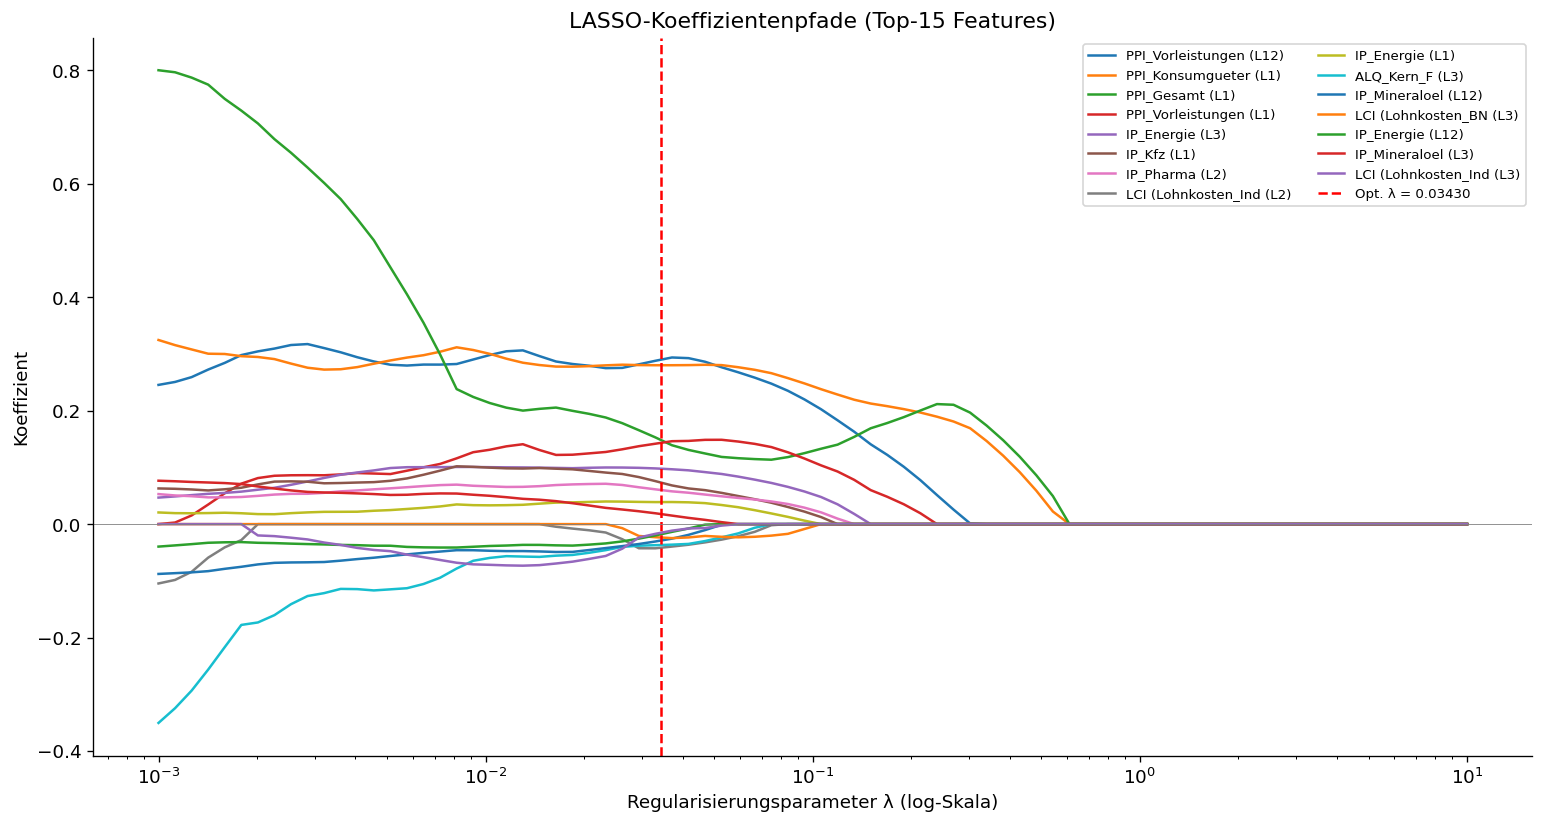

Abbildung gespeichert: fig_06_lasso_path.png


In [16]:
from sklearn.linear_model import lasso_path, ridge_regression

# LASSO-Pfad: Koeffizienten als Funktion von λ
alphas_path = np.logspace(-3, 1, 80)
alphas_lasso_path, coefs_lasso, _ = lasso_path(
    X_train_s, y_train, alphas=alphas_path, max_iter=10000
)

# Nur die 15 wichtigsten Features anzeigen (nach |Koeff.| bei opt. λ)
top_idx = np.argsort(np.abs(lasso_cv.coef_))[::-1][:15]
feat_names = X.columns.tolist()

fig, ax = plt.subplots(figsize=(13, 7))
for i in top_idx:
    ax.semilogx(alphas_lasso_path, coefs_lasso[i, :], linewidth=1.5,
                label=feat_names[i].replace("_L", " (L").replace("L", "L") + ")")

ax.axvline(lambda_lasso, color="red", linestyle="--", linewidth=1.5,
           label=f"Opt. λ = {lambda_lasso:.5f}")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("LASSO-Koeffizientenpfade (Top-15 Features)")
ax.set_xlabel("Regularisierungsparameter λ (log-Skala)")
ax.set_ylabel("Koeffizient")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("results/figures/fig_06_lasso_path.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_06_lasso_path.png")


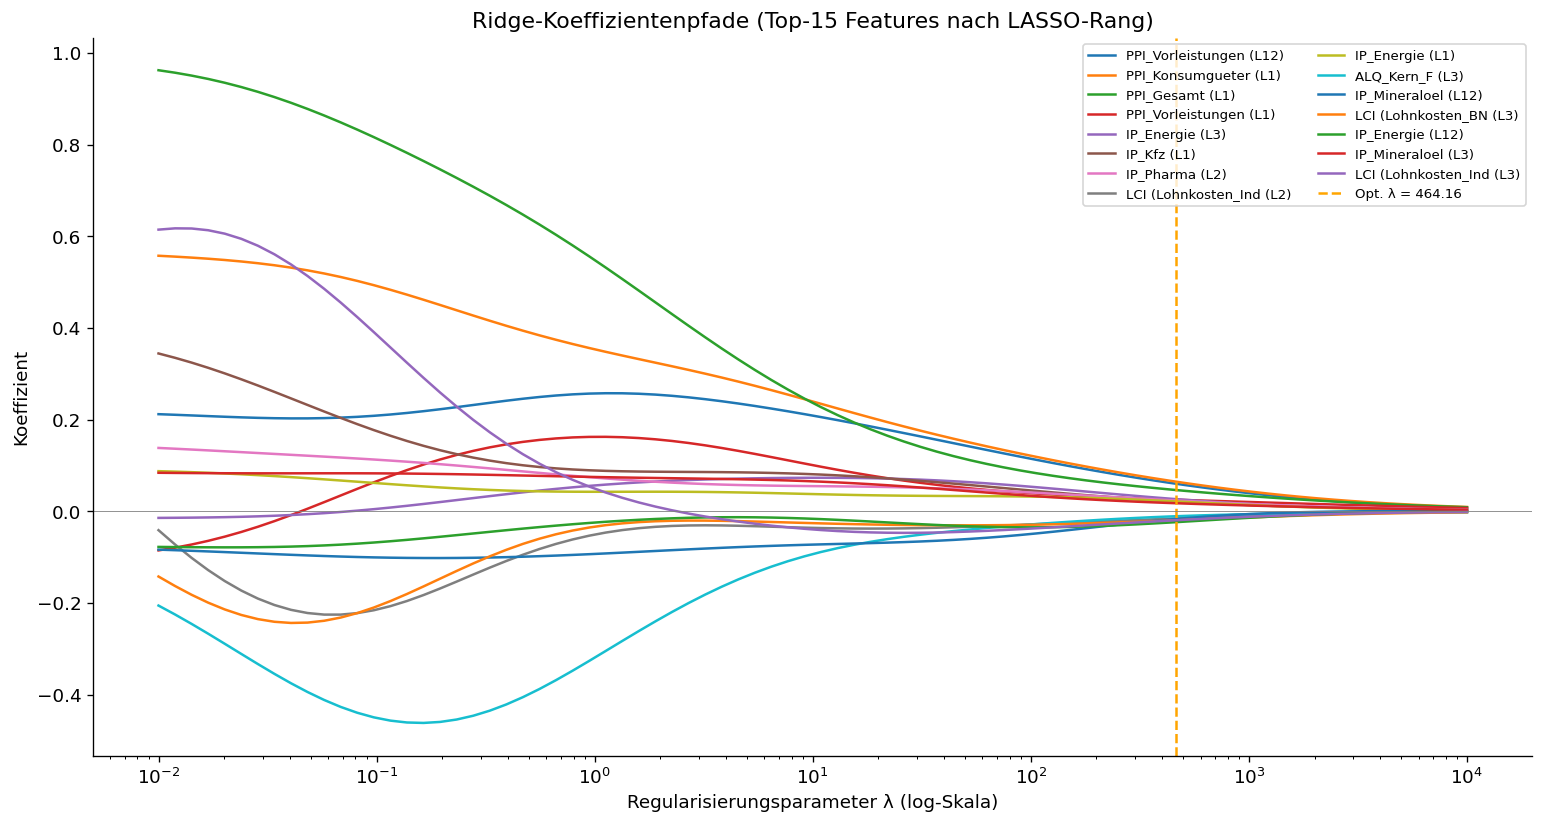

Abbildung gespeichert: fig_07_ridge_path.png


In [17]:
# Ridge-Pfad: Schrumpfung aller Koeffizienten Richtung null (aber nie = null)
alphas_ridge_path = np.logspace(-2, 4, 80)
coefs_ridge_path = np.array([
    Ridge(alpha=a).fit(X_train_s, y_train).coef_
    for a in alphas_ridge_path
])

fig, ax = plt.subplots(figsize=(13, 7))
for i in top_idx:
    ax.semilogx(alphas_ridge_path, coefs_ridge_path[:, i], linewidth=1.5,
                label=feat_names[i].replace("_L", " (L") + ")")

ax.axvline(lambda_ridge, color="orange", linestyle="--", linewidth=1.5,
           label=f"Opt. λ = {lambda_ridge:.2f}")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("Ridge-Koeffizientenpfade (Top-15 Features nach LASSO-Rang)")
ax.set_xlabel("Regularisierungsparameter λ (log-Skala)")
ax.set_ylabel("Koeffizient")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("results/figures/fig_07_ridge_path.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_07_ridge_path.png")


LASSO selektiert 29 von 165 Features:

PPI_Vorleistungen_L12        0.289527
PPI_Konsumgueter_L1          0.280296
PPI_Gesamt_L1                0.148731
PPI_Vorleistungen_L1         0.143045
IP_Energie_L3                0.097759
IP_Kfz_L1                    0.073484
IP_Pharma_L2                 0.060240
LCI_Lohnkosten_Ind_L2       -0.041782
IP_Energie_L1                0.038838
ALQ_Kern_F_L3               -0.036409
IP_Mineraloel_L12           -0.029067
LCI_Lohnkosten_BN_L3        -0.023251
IP_Energie_L12              -0.018023
IP_Mineraloel_L3             0.017843
LCI_Lohnkosten_Ind_L3       -0.015742
IP_Pharma_L1                 0.014820
IP_Metall_Grundstoffe_L1     0.014434
BS_Auftragsbestand_L3        0.011026
PPI_Konsumgueter_L12         0.010398
ALQ_Frauen_L1               -0.010277
BS_Absatzpreise_L3           0.010181
IP_Mineraloel_L2             0.009160
LCI_Lohnkosten_Ind_L12       0.007634
BS_Auftragsbestand_L6        0.006557
PPI_Gesamt_L12               0.006165
BS_Auftrags

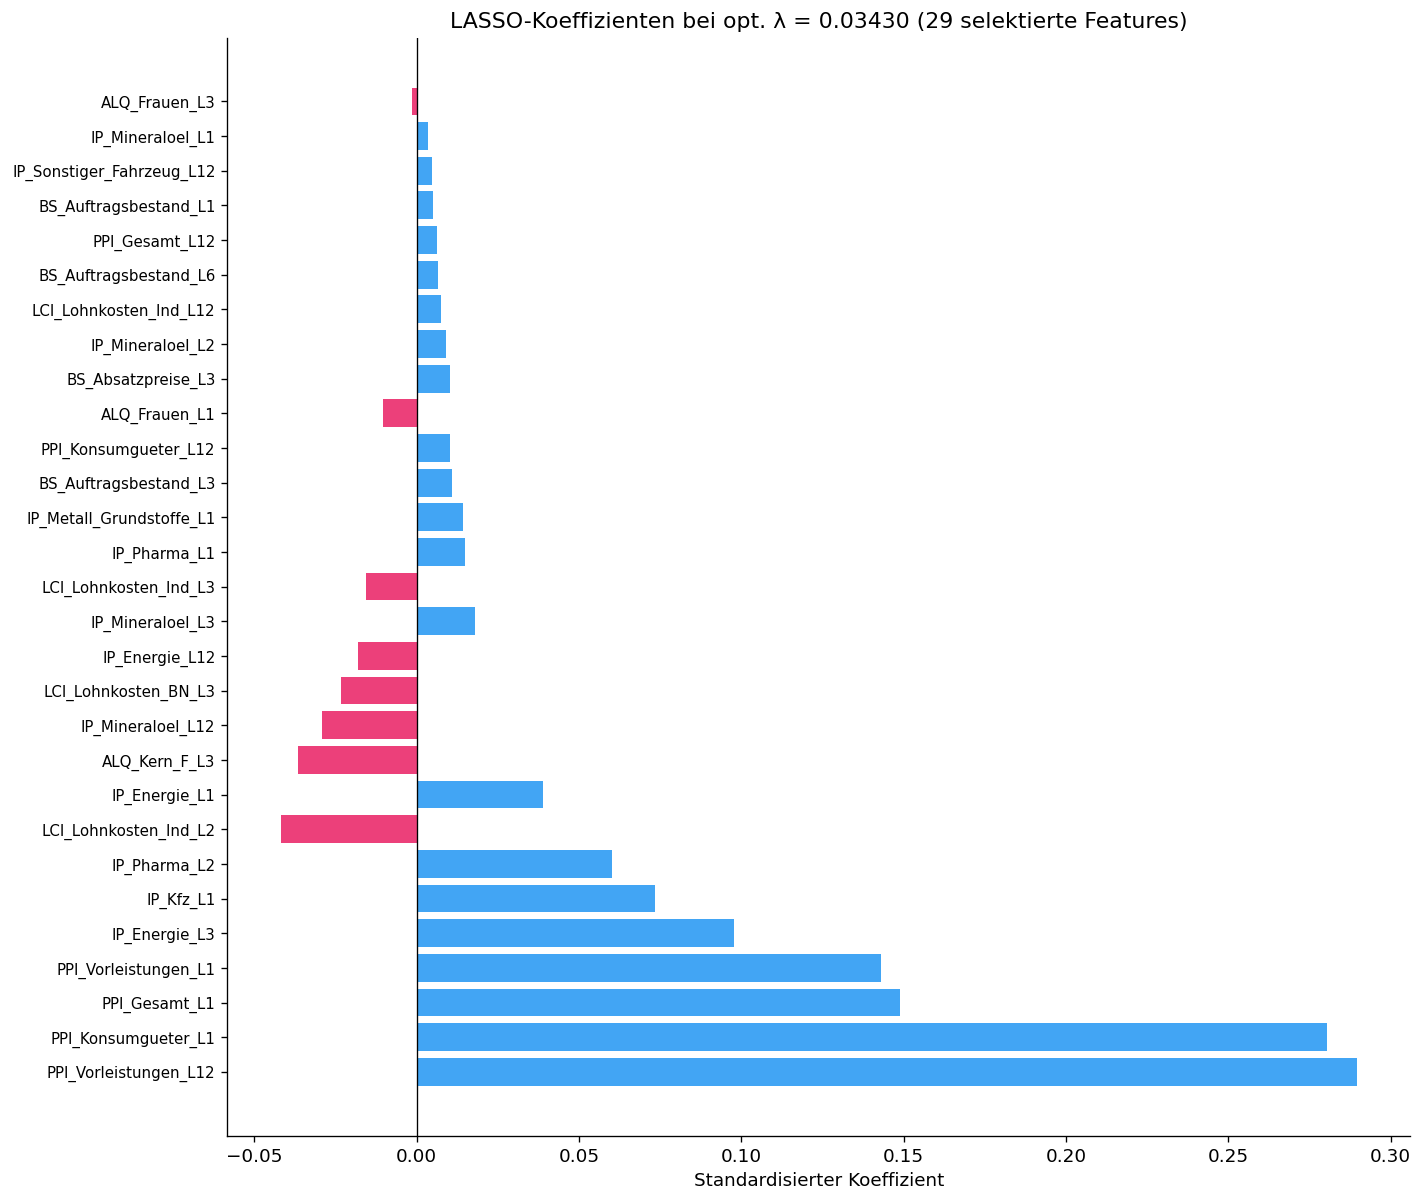


Abbildung gespeichert: fig_08_lasso_selektion.png


In [18]:
# Selektierte Variablen beim optimalen LASSO
lasso_coefs = pd.Series(lasso_cv.coef_, index=X.columns)
selected = lasso_coefs[lasso_coefs != 0].sort_values(key=np.abs, ascending=False)

print(f"LASSO selektiert {len(selected)} von {len(lasso_coefs)} Features:\n")
print(selected.to_string())

# Koeffizientendiagramm
fig, ax = plt.subplots(figsize=(12, max(5, len(selected) * 0.35)))
colors_sel = ["#E91E63" if v < 0 else "#2196F3" for v in selected.values]
ax.barh(range(len(selected)), selected.values, color=colors_sel, alpha=0.85)
ax.set_yticks(range(len(selected)))
ax.set_yticklabels(selected.index, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"LASSO-Koeffizienten bei opt. λ = {lambda_lasso:.5f} "
             f"({len(selected)} selektierte Features)")
ax.set_xlabel("Standardisierter Koeffizient")
plt.tight_layout()
plt.savefig("results/figures/fig_08_lasso_selektion.png", bbox_inches="tight")
plt.show()
print("\nAbbildung gespeichert: fig_08_lasso_selektion.png")


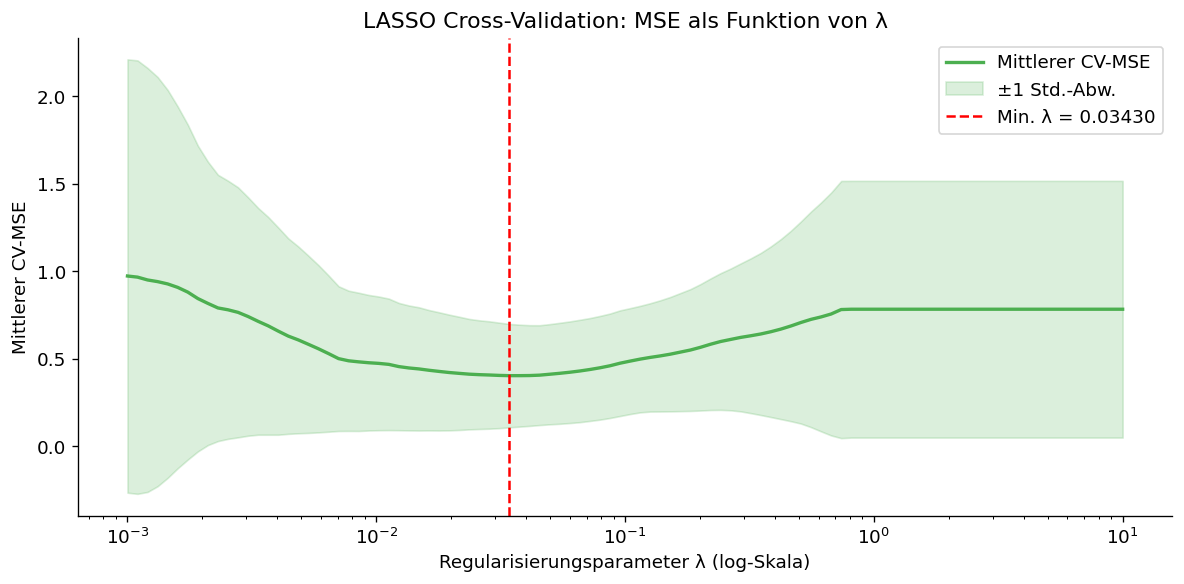

Abbildung gespeichert: fig_09_lasso_cv_path.png


In [19]:
# Cross-Validation MSE als Funktion von λ (für LASSO)
cv_mses = np.mean(lasso_cv.mse_path_, axis=1)
cv_stds = np.std(lasso_cv.mse_path_, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(lasso_cv.alphas_, cv_mses, color="#4CAF50", linewidth=2,
            label="Mittlerer CV-MSE")
ax.fill_between(lasso_cv.alphas_,
                cv_mses - cv_stds,
                cv_mses + cv_stds,
                alpha=0.2, color="#4CAF50", label="±1 Std.-Abw.")
ax.axvline(lambda_lasso, color="red", linestyle="--", linewidth=1.5,
           label=f"Min. λ = {lambda_lasso:.5f}")
ax.set_title("LASSO Cross-Validation: MSE als Funktion von λ")
ax.set_xlabel("Regularisierungsparameter λ (log-Skala)")
ax.set_ylabel("Mittlerer CV-MSE")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/fig_09_lasso_cv_path.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_09_lasso_cv_path.png")


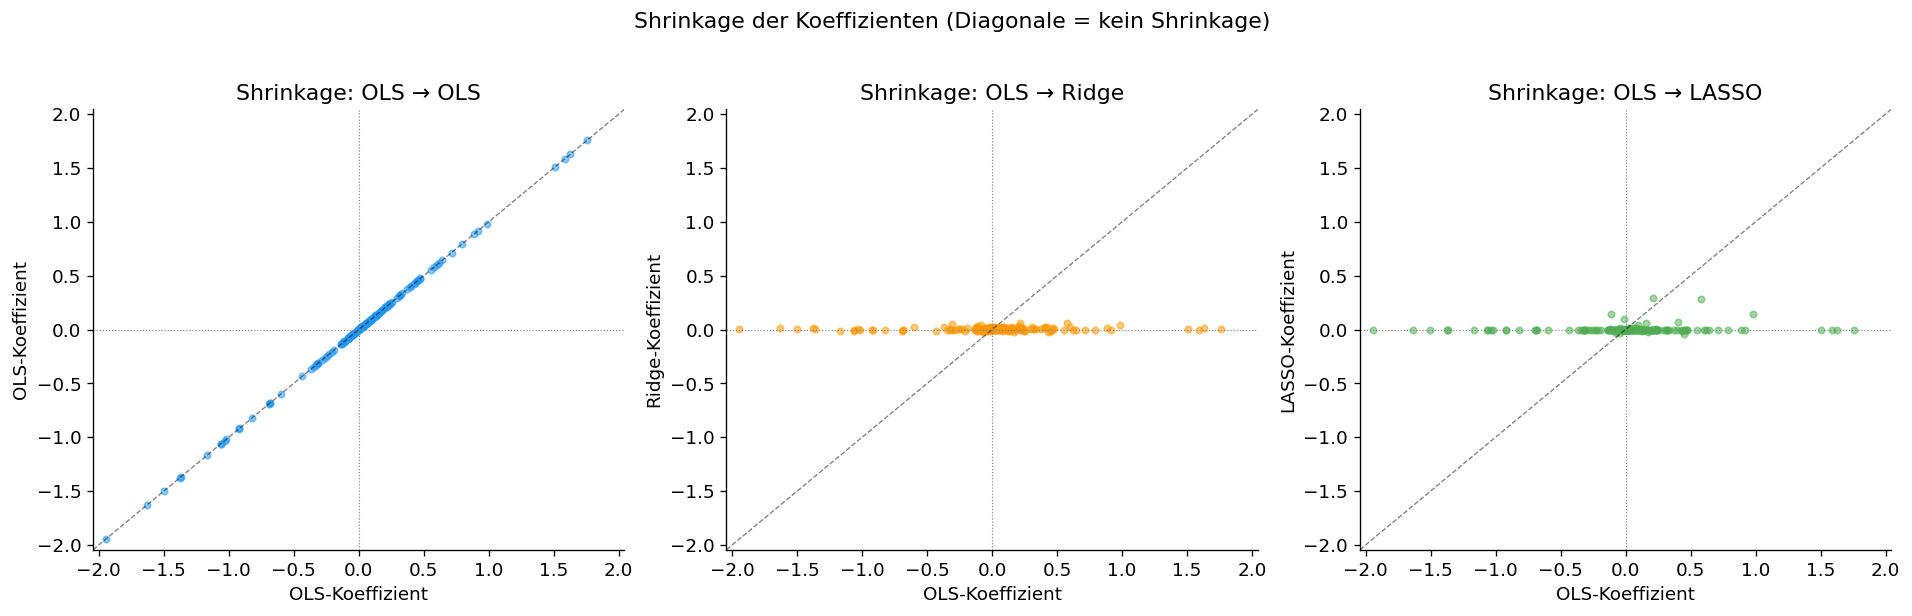

Abbildung gespeichert: fig_10_shrinkage.png


In [20]:
# Shrinkage-Vergleich: OLS vs. Ridge vs. LASSO Koeffizienten
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, coef), col in zip(
    axes,
    [("OLS", ols.coef_), ("Ridge", ridge_cv.coef_), ("LASSO", lasso_cv.coef_)],
    [COLORS["OLS"], COLORS["Ridge"], COLORS["LASSO"]],
):
    ax.scatter(ols.coef_, coef, alpha=0.5, s=15, color=col)
    ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
    ax.axvline(0, color="gray", linewidth=0.7, linestyle=":")
    lim = max(np.abs(ols.coef_).max(), np.abs(coef).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=0.8, alpha=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(f"Shrinkage: OLS → {name}")
    ax.set_xlabel("OLS-Koeffizient")
    ax.set_ylabel(f"{name}-Koeffizient")

plt.suptitle("Shrinkage der Koeffizienten (Diagonale = kein Shrinkage)", y=1.02)
plt.tight_layout()
plt.savefig("results/figures/fig_10_shrinkage.png", bbox_inches="tight")
plt.show()
print("Abbildung gespeichert: fig_10_shrinkage.png")


## 6. Interpretation & Fazit

In [ ]:
print("=" * 75)
print("ZUSAMMENFASSUNG DER ERGEBNISSE")
print("=" * 75)
print(f"Datensatz:  {X.shape[0]} Monate, {X.shape[1]} Features")
print(f"Zeitraum:   {y.index[0].strftime('%Y-%m')} – {y.index[-1].strftime('%Y-%m')}")
print(f"Test-Split: {len(y_test)} Monate (chronologisch)")
print()
print(f"{'Modell':<14} {'Test-RMSE':>10} {'RMSE/RW':>9} {'Test-R²':>10} {'Koeff.≠0':>10}")
print("-" * 58)
for name, rmse_val, r2_val, nz in [
    ("Random Walk",  rmse_rw_test,            r2_rw_test,          "-"),
    ("AR(p)",        rmse_ar_test,            r2_ar_test,          str(len(AR_LAGS))),
    ("OLS",          np.sqrt(mse_ols_test),   r2_ols_test,         str(int(np.sum(ols.coef_ != 0)))),
    ("Ridge",        np.sqrt(mse_ridge_test), r2_ridge_test,       str(len(ridge_cv.coef_))),
    ("LASSO",        np.sqrt(mse_lasso_test), r2_lasso_test,       str(int(np.sum(lasso_cv.coef_ != 0)))),
    ("LASSO+HVPI",   rmse_lasso_plus_test,    r2_lasso_plus_test,  str(n_nonzero_plus)),
]:
    rel = "1.000 (Ref)" if name == "Random Walk" else f"{rmse_val/rmse_rw_test:.3f}"
    print(f"{name:<14} {rmse_val:>10.4f} {rel:>9} {r2_val:>10.4f} {nz:>10}")
print("=" * 75)

best = results["Test RMSE"].astype(float).idxmin()
print(f"\nBestes Modell nach Test-RMSE: {best}")
print()
print("Selektierte Variablengruppen (LASSO):")
for grp, prefix in [
    ("Industrieproduktion", "IP_"),
    ("Business Surveys",    "BS_"),
    ("Produzentenpreise",   "PPI_"),
    ("Arbeitsmarkt",        "ALQ_"),
    ("Lohnkosten",          "LCI_"),
]:
    sel_grp = [c for c in selected.index if prefix in c]
    if sel_grp:
        print(f"  {grp}: {len(sel_grp)} Feature(s) – {sel_grp}")